=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


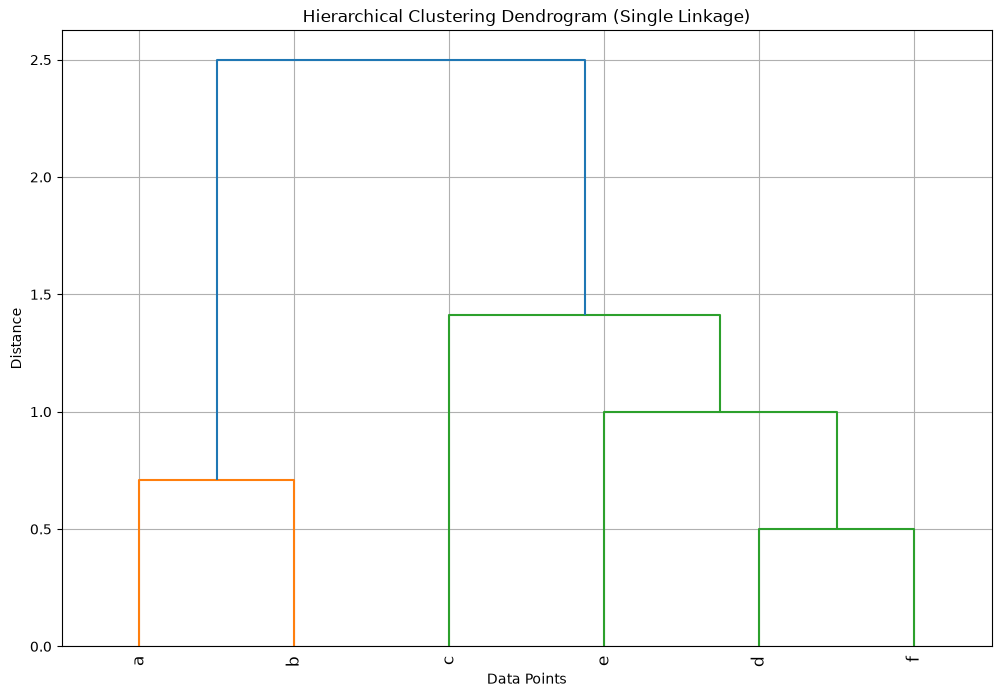

In [3]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5], # f
])

# 2. Hitung Distance  Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                            columns=['a', 'b', 'c', 'd', 'e', 'f'],
                            index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


###### Pada cell ini saya mengimpor library yang dibutuhkan, yaitu numpy, pandas, matplotlib, serta fungsi linkage, dendrogram, pdist, dan squareform dari scipy. Setelah itu dibuat dataset sederhana berisi 6 titik (a sampai f) yang masing-masing punya 2 nilai koordinat. Jarak antar titik dihitung dengan Euclidean distance menggunakan pdist, lalu diubah menjadi tabel matriks jarak dengan squareform supaya lebih mudah dibaca. Dari tabel terlihat jarak paling dekat adalah d dan f (0,5), sedangkan yang paling jauh adalah a dan c (5,66).

###### Selanjutnya clustering dilakukan dengan single linkage, yaitu menggabungkan klaster berdasarkan jarak terdekat antar anggotanya. Hasilnya ditampilkan dalam bentuk dendrogram. Dari dendrogram terlihat d dan f digabung paling awal, disusul a dan b, lalu e dan c masuk ke kelompok d dan f. Pada akhirnya data terbagi menjadi dua kelompok besar, yaitu kelompok a, b (oranye) dan kelompok c, d, e, f (hijau).

In [10]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


###### Pada percobaan kedua, saya membaca dataset Mall_Customers.csv menggunakan pandas lalu menampilkan 5 data pertamanya. Dataset ini sama seperti praktikum K-Means sebelumnya, berisi data 200 pelanggan mall dengan kolom CustomerID, Genre, Age, Annual Income, dan Spending Score. Path /content/ saya hapus karena itu path Google Colab, sedangkan saya menjalankannya di VS Code.

In [11]:
x = df.iloc[:, [3, 4]].values

###### Cell ini mengambil kolom indeks 3 dan 4, yaitu Annual Income dan Spending Score, lalu menyimpannya ke variabel x dalam bentuk array dengan .values. Dua kolom ini dipilih karena tujuan percobaan ini adalah mengelompokkan pelanggan berdasarkan pendapatan dan pola belanjanya.

In [13]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape


(200, 2)

###### Data x di-scaling menggunakan StandardScaler supaya setiap fitur punya rata-rata 0 dan standar deviasi 1. Tujuannya agar kedua fitur punya pengaruh yang seimbang saat menghitung jarak. Hasil scaled_data.shape adalah (200, 2), artinya ada 200 data dengan 2 fitur.

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

###### Pada cell ini hierarchical clustering dilakukan pada data yang sudah di-scaling menggunakan method complete dan jarak euclidean. Complete linkage menggabungkan klaster berdasarkan jarak terjauh antar anggotanya, sehingga klaster yang terbentuk cenderung lebih rapat. Hasil penggabungannya disimpan di variabel clustering untuk digambar sebagai dendrogram.

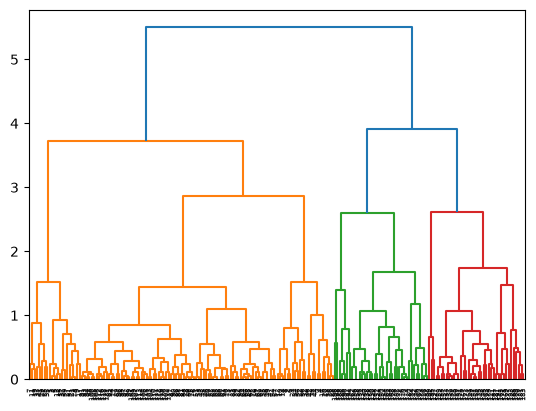

In [15]:

import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

###### Hasil clustering ditampilkan dalam bentuk dendrogram. Karena datanya ada 200, label di bagian bawah terlihat bertumpuk dan tidak terbaca, tapi itu normal. Dari dendrogram terlihat data terbagi menjadi tiga kelompok utama, yaitu oranye, hijau, dan merah. Kelompok oranye adalah yang paling besar. Pembagian ini bisa dipakai untuk mengelompokkan pelanggan berdasarkan pola pengeluarannya, sehingga pihak mall bisa memberi penawaran yang lebih sesuai untuk setiap kelompok.

#### Tugas


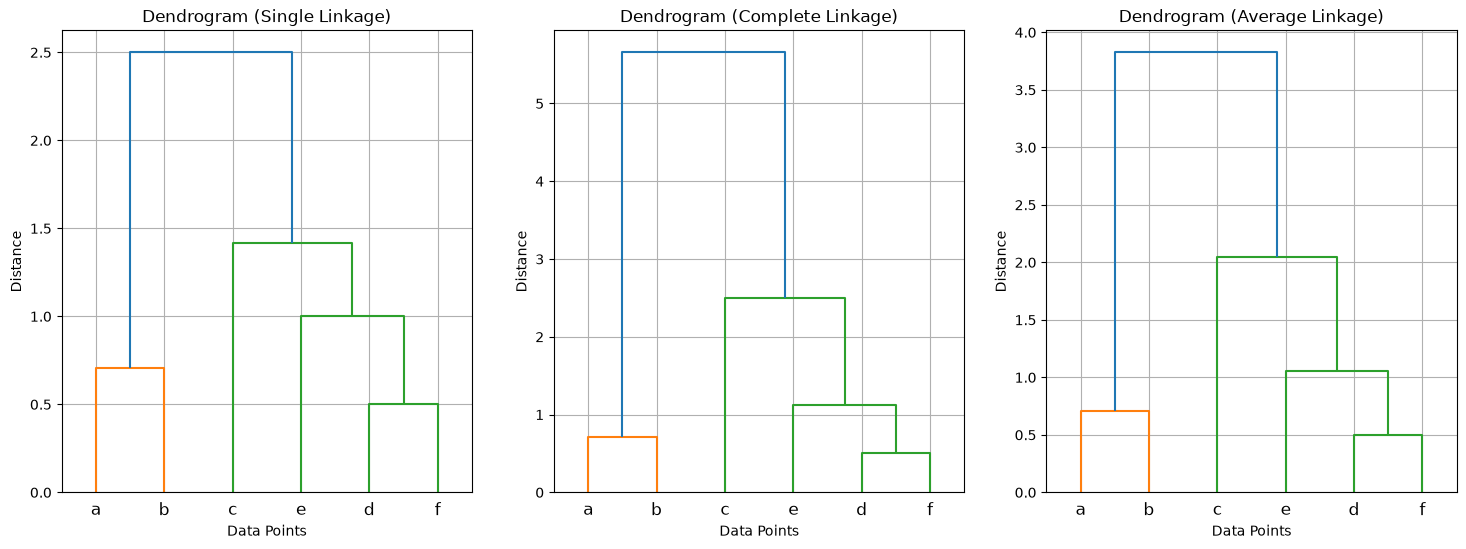

In [16]:
# Tugas: membandingkan single, complete, dan average linkage
methods = ['single', 'complete', 'average']
labels = ['a', 'b', 'c', 'd', 'e', 'f']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, method in zip(axes, methods):
    linked = linkage(data, method=method)
    dendrogram(linked, labels=labels, ax=ax)
    ax.set_title(f"Dendrogram ({method.capitalize()} Linkage)")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    ax.grid(True)

plt.show()

Dari hasil ketiga dendrogram, bentuk dan urutan penggabungan klasternya sama. Pertama d dan f digabung karena jaraknya paling dekat (0,5), lalu a dan b, kemudian e masuk ke klaster d dan f, lalu c, dan terakhir kedua kelompok besar digabung menjadi satu. Jadi ketiga metode sama-sama membagi data menjadi dua kelompok utama, yaitu kelompok a, b dan kelompok c, d, e, f.

Perbedaannya ada di tinggi garis penggabungan. Single linkage memakai jarak terdekat antar anggota klaster, jadi tinggi penggabungannya paling rendah dengan penggabungan terakhir di jarak 2,5. Complete linkage memakai jarak terjauh antar anggota, sehingga penggabungan terakhirnya paling tinggi, yaitu 5,66 (jarak a ke c). Average linkage memakai rata-rata jarak semua pasangan anggota, jadi hasilnya berada di tengah-tengah, yaitu 3,83.

Karena datanya hanya 6 titik dan kelompoknya sudah terpisah jelas, hasil pengelompokannya sama saja. Tapi pada dataset yang lebih besar dan lebih rumit, perbedaan cara menghitung jarak ini bisa membuat hasil klasternya berbeda. Single linkage cenderung membentuk klaster yang memanjang seperti rantai, sedangkan complete linkage cenderung membentuk klaster yang lebih rapat.